## Mapa

Nesse notebook é produzido o mapa coroplético

In [ ]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import mapclassify
from matplotlib import cm
from matplotlib.ticker import FormatStrFormatter
from matplotlib_scalebar.scalebar import ScaleBar
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from utils.load_shp import load_shp
from utils.load_csv import load_csv
from utils.save_graph import save_graph

In [204]:
mapa = load_shp("mapa.shp")

dados = load_csv("dados.csv")

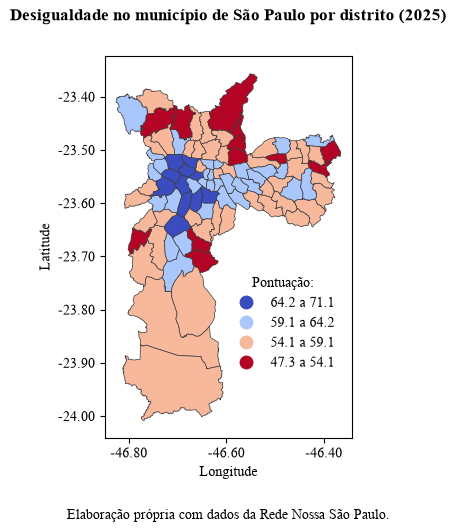

In [205]:
mapa_wgs84 = mapa.to_crs(epsg=4326)

plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = [
    "Times New Roman",
    "Liberation Serif",
    "DejaVu Serif"
]

fig, ax = plt.subplots(figsize=(8, 5))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

mapa_wgs84.plot(
    column="pontuacao",
    cmap="coolwarm_r",
    linewidth=0.5,
    edgecolor="#3a3a3a",
    ax=ax,
    legend=True,
    scheme="NaturalBreaks",
    k=4,
    legend_kwds={
        "loc": "center right",
        "bbox_to_anchor": (1.5, 0.5),
        "fmt": "{:.1f}",
        "title": "Pontuação:",
        "frameon": False,
        "fontsize": 10,
        "title_fontsize": 10,
    },
    missing_kwds={
        "color": "lightgrey",
        "edgecolor": "white",
        "label": "Sem dado"
    }
)

leg = ax.get_legend()

handles = leg.legend_handles
labels = [t.get_text() for t in leg.get_texts()]

labels = [label.replace(", ", " a ") for label in labels]

leg.remove()

ax.legend(
    handles[::-1],
    labels[::-1],
    title="Pontuação:",
    loc="center right",
    bbox_to_anchor=(0.98, 0.3), #1.5, 0.5
    frameon=False,
    fontsize=10,
    title_fontsize=10
)

ax.xaxis.set_major_formatter(FormatStrFormatter("%.2f"))
ax.yaxis.set_major_formatter(FormatStrFormatter("%.2f"))

ax.set_xlabel("Longitude", fontsize=10)
ax.set_ylabel("Latitude", fontsize=10)

ax.tick_params(axis="both", labelsize=10)

ax.set_title(
    "Desigualdade no município de São Paulo por distrito (2025)",
    fontsize=12,
    fontweight="bold",
    pad=26
)

fig.text(
    0.5,
    -0.05,
    "Elaboração própria com dados da Rede Nossa São Paulo.",
    ha="center",
    fontsize=10,
    color="black"
)

plt.tight_layout()
plt.show()

C:\Users\caiod\AppData\Local\Temp\ipykernel_20784\4292987491.py:200: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0,0.04,1,0.95])


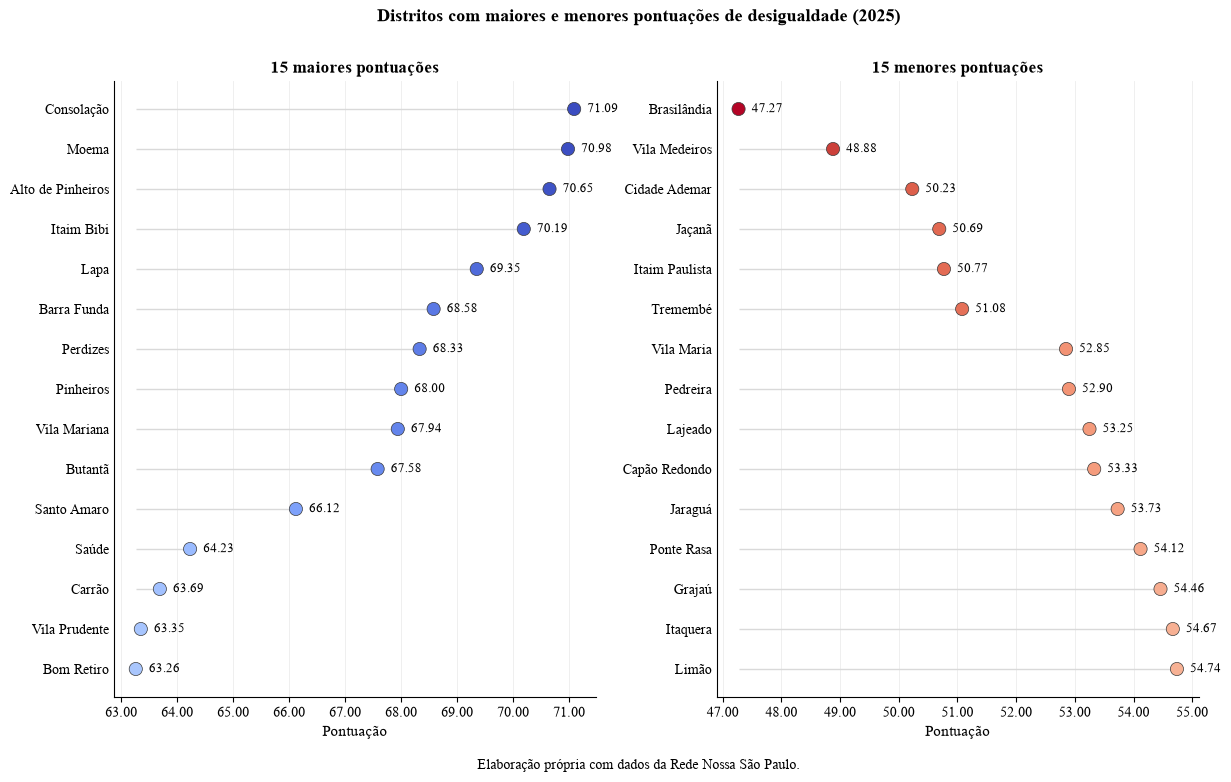

In [ ]:
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = [
    "Times New Roman",
    "Liberation Serif",
    "DejaVu Serif"
]

ranking = (
    dados[["distrito", "pontuacao"]]
    .sort_values("pontuacao", ascending=False)
    .reset_index(drop=True)
)

top15 = ranking.head(15).copy()

bottom15 = (
    ranking.tail(15)
    .sort_values("pontuacao", ascending=True)
    .reset_index(drop=True)
)

norm = mpl.colors.Normalize(
    vmin=ranking["pontuacao"].min(),
    vmax=ranking["pontuacao"].max()
)

cores_top = cm.coolwarm_r(norm(top15["pontuacao"]))
cores_bottom = cm.coolwarm_r(norm(bottom15["pontuacao"]))

fig, (ax1, ax2) = plt.subplots(
    1,
    2,
    figsize=(14, 8),
    gridspec_kw={"wspace":0.25}
)

fig.patch.set_facecolor("white")

def painel(ax, dados, cores, titulo):

    ax.set_facecolor("white")

    xmin = dados["pontuacao"].min()

    ax.hlines(
        y=range(len(dados)),
        xmin=xmin,
        xmax=dados["pontuacao"],
        color="#d9d9d9",
        linewidth=1
    )

    ax.scatter(
        dados["pontuacao"],
        range(len(dados)),
        s=90,
        color=cores,
        edgecolor="#3a3a3a",
        linewidth=0.5,
        zorder=3
    )

    offset = (
        dados["pontuacao"].max() -
        dados["pontuacao"].min()
    ) * 0.03

    for y, valor in enumerate(dados["pontuacao"]):

        ax.text(
            valor + offset,
            y,
            f"{valor:.2f}",
            va="center",
            fontsize=9
        )

    ax.set_yticks(range(len(dados)))
    ax.set_yticklabels(
        dados["distrito"],
        fontsize=10
    )

    ax.invert_yaxis()

    ax.grid(
        axis="x",
        color="#ececec",
        linewidth=0.6
    )

    ax.set_axisbelow(True)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.spines["left"].set_linewidth(0.8)
    ax.spines["bottom"].set_linewidth(0.8)

    ax.tick_params(
        axis="y",
        length=0
    )

    ax.tick_params(
        axis="x",
        labelsize=10
    )

    ax.xaxis.set_major_formatter(
        FormatStrFormatter("%.2f")
    )

    ax.set_xlabel(
        "Pontuação",
        fontsize=11
    )

    ax.set_title(
        titulo,
        fontsize=12,
        fontweight="bold"
    )

painel(
    ax1,
    top15,
    cores_top,
    "15 maiores pontuações"
)

painel(
    ax2,
    bottom15,
    cores_bottom,
    "15 menores pontuações"
)

fig.suptitle(
    "Distritos com maiores e menores pontuações de desigualdade (2025)",
    fontsize=13,
    fontweight="bold",
    y=0.97
)

fig.text(
    0.5,
    0.02,
    "Elaboração própria com dados da Rede Nossa São Paulo.",
    ha="center",
    fontsize=10
)

plt.tight_layout(rect=[0,0.04,1,0.95])

plt.show()